# Analisis estadistico

El objetivo de este analisis estadistico sera:
1. Auditoria de estructura e integridad
2. Analisis univariado y distribucion
3. Analisis bivariado y relacional
4. Estadistica inferencial y validacion de hipotesis
5. Preparacion para Feature Engineering (Basado en EDA)

In [2]:
# Instalacion de librerias

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

In [3]:

# Usamos la ruta completa al objeto Path para evitar cualquier confusión de nombres
ruta = pathlib.Path(r"E:\ROAD_TO_DATA_SCIENCE\proyectos_programacion\python\SALARYLENS\SalaryLens-Predictor-de-Retorno-Laboral-con-Machine-Learning\data\raw\job_salary_prediction_dataset.csv")

# comprobacion de carga del dataset
match ruta.exists():
    case True:
        print("Dataset encontrado en la ruta correctamente, leyendo datos...")
        # Instanciando el dataset
        df = pd.read_csv(ruta)
        display(df.head())
    case False:
        print("El dataset no ha siddo encontrado en esa ruta")



Dataset encontrado en la ruta correctamente, leyendo datos...


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


### Auditoria de Estructura e Integridad

#### Clasificacion tecnica de features

**Tipos de datos:**
- **job_title =** Variable cualitativa categorica
- **experience_years =** Variable cuantitativa discreta
- **education_level =** Variable cualitativa ordinal
- **skills_count =** Variable cuantitativa discreta
- **industry =** Cualitativa nominal
- **company_size =** Cualitativa ordinal
- **location =** Cualitava nominal
- **remote_work =** Cualitativa ordinal
- **certifications =** Cuantitativa discreta
- **salary =** Cuantitativa discreta

#### Analisis de Cardinalidad

In [4]:
df.value_counts("job_title")

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

Observando el numero de cada una de las distintas profesiones encontramos que todas pertenecen al sector tecnologico, asi que este analisis tendra en cuenta solo profesiones dentro del sector tecnologico

### Primer vistazo de los datos

In [5]:
df.shape # Cantidad de filas y columnas

(250000, 10)

In [6]:
df.dtypes # Tipos de datos de cada feature

job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object

In [7]:
df.info() # 

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [8]:
df.describe() # Observar estadisticas basicas del dataset

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [9]:
df.isnull().sum() # Revisar el numero de nulos por feature

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [10]:
df.duplicated().sum() # Ver el numero de filas duplicadas

np.int64(0)

In [11]:
df.nunique() # Revisar la cardinalidad [numero de elementos distintos (categorias) por feature]

job_title               12
experience_years        21
education_level          5
skills_count            19
industry                10
company_size             5
location                10
remote_work              3
certifications           6
salary              118956
dtype: int64

In [12]:
df['job_title'].value_counts()

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

In [13]:
for key, value in df.items():
    print(f"Distribucion de clase de la columna {key}\n")

    print(f"{df[key].value_counts()}\n")

    


Distribucion de clase de la columna job_title

job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

Distribucion de clase de la columna experience_years

experience_years
14    12166
18    12102
15    12052
1     12011
4     12001
7     11981
20    11958
2     11950
12    11944
16    11908
3     11890
19    11875
5     11862
6     11860
9     11856
8     11822
0     11804
10    11777
11    11747
17    11735
13    11699
Name: count, dtype: int64

Distribucion de clase de la columna education_level

education_level
Master         50352
High School    50065
Bachelor       49950
PhD           

### Analisis Exploratorio de Datos (EDA)

#### 1.- Analisis de valores nulos

In [14]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

No se encuentran valores nulos en el dataset, esto no es lo mas comun pero al ser un dataset de kaggle probablemente ya llevo algun tipo de tratamiento de limpieza de los datos.

#### 2.- Analisis de duplicados

In [15]:
df.duplicated().sum()

np.int64(0)

No se encuentran filas duplicadas en el dataset

#### 3.- Analisis de outliers (datos atipicos)

##### 3.1.- Visualizacion de distribucion
Primero generamos boxplots para nuestras variables numericas para visualizar la dispersion y la presencia de puntos fuera de los "bigotes".

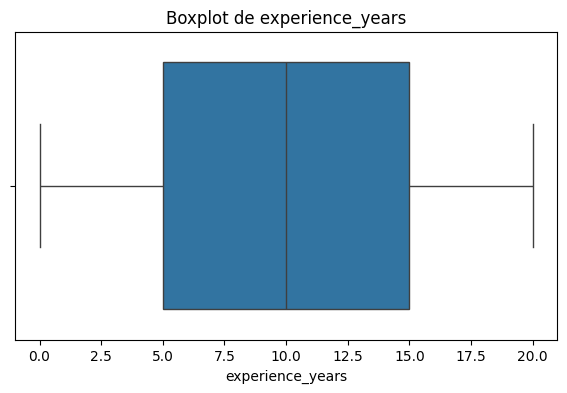

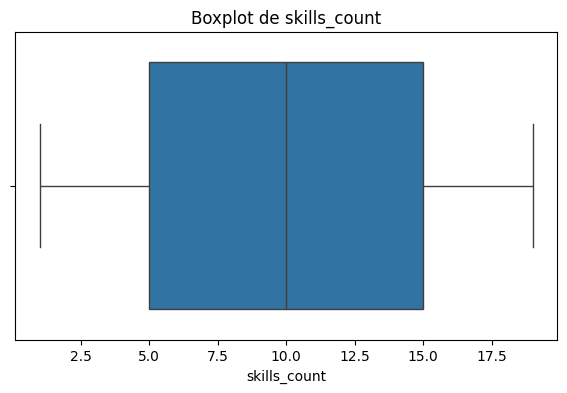

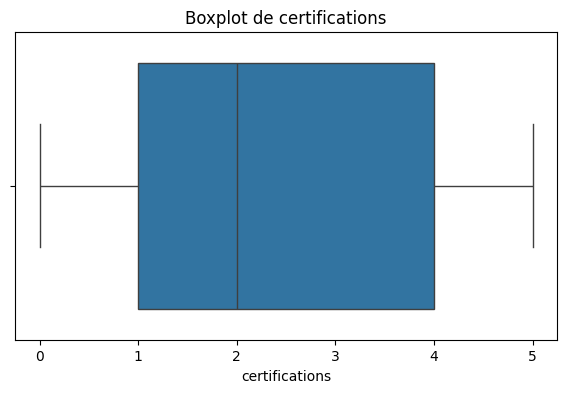

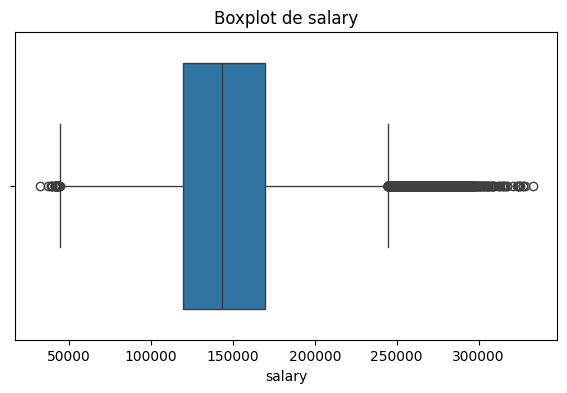

In [91]:

# Extraemos solo las features de tipo numerico del dataset

num_columns = df.select_dtypes(include = ["int64", "float64"]).columns

# A traves de un bucle for accedemos a todas esas columnas y exportamos los graficos
for col in num_columns:
    # Definimos el tamanioo de la figura
    fig = plt.figure(figsize=(7,4))

    # Imprimimos la figura
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

##### 3.2. Calculo de limites e identificacion
Calculamos los limites tecnicos para cuantificar el impacto de estos outliers en nuestro dataset

In [103]:
resumen_outliers = []
for col in num_columns:

    q1 = df[col].quantile(0.25) # Primer cuantil
    q3 = df[col].quantile(0.75) # Tercer cuartil
    IQR = q3 - q1 

    # Calculamos los limites
    limite_inf = q1 - 1.5 * IQR
    limite_sup = q3 + 1.5 * IQR

    IQR = q3 - q1 
    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)] # Buscamos los valores que sean menores y mayores al rango intercuartil
    porcentaje = (len(outliers) / len(df)) * 100

    resumen_outliers.append({
        "Variable" : col,
        "Limite_inferior" : round(limite_inf, 2),
        "Limite_superior" : round(limite_sup, 2),
        "Por_outliers" : f"{round(porcentaje, 2)}%"
    })

pd.DataFrame(resumen_outliers)

,Variable,Limite_inferior,Limite_superior,Por_outliers
0,experience_years,-10.0,30.0,0.0%
1,skills_count,-10.0,30.0,0.0%
2,certifications,-3.5,8.5,0.0%
3,salary,44157.0,244693.0,0.93%


##### 3.3. Observando outliers en salary
Observamos graficamente y obtenemos el valor exacto desde el cual el salario llega a ser un outlier

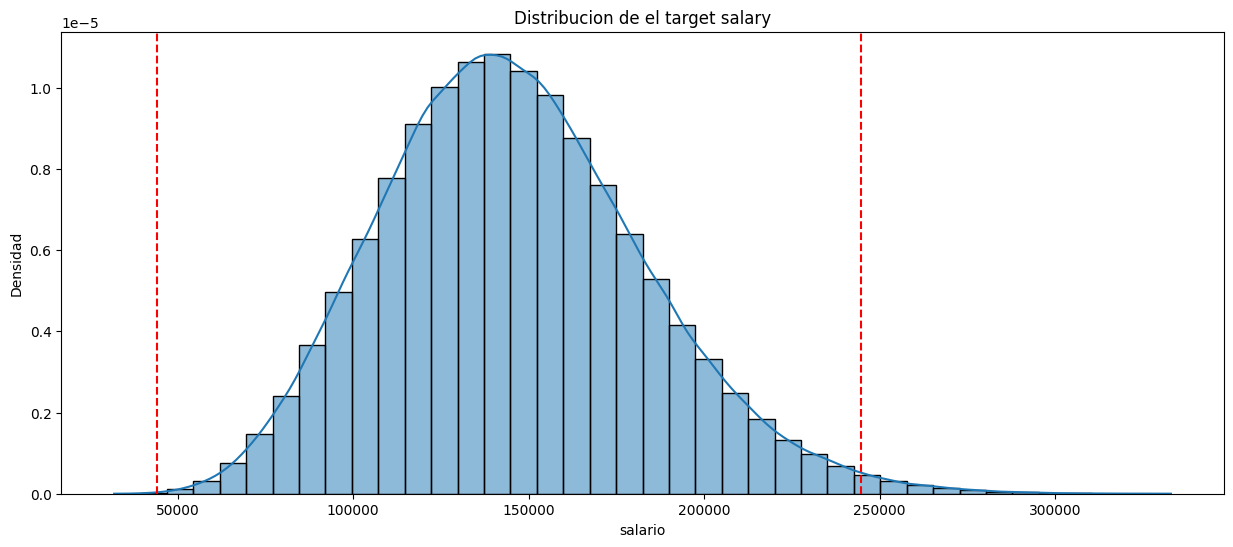

In [101]:
plt.figure(figsize = (15,6))
sns.histplot(df["salary"], kde=True, stat="density", bins=40)
plt.title("Distribucion de el target salary")
plt.xlabel("salario")
plt.ylabel("Densidad")
plt.axvline(x = limite_sup, color="red", linestyle="--")
plt.axvline(x= limite_inf, color="red", linestyle="--")
plt.show()

##### 3.3. Interpretacion y Decision
Tras el analisis visual y estadistico observamos lo siguiente:
- Salary: Se detecta un 0.93% de outliers.
- Certificaciones: El limite inferior calculado estadisticamente es -10. Dado que esta variable tiene un limite natural en 0, ajustamos el umbral inferior. Esto indica que no existen valores atipicos en el rango de menor numero de certificaciones, no se encuentra ningun outlier en esta feature

**Accion a tomar:** Se 